# Klasifikasi Kesegaran Daging Sapi — SURF-BoVW + HSV + SVM
### Notebook Penelitian | Abrar Wahid | 22.14.1.0088 | UNMA 2026

**Perubahan dari versi sebelumnya (v2 — Metodologis Bersih):**
- ✅ **FIX KRITIS #1 — BoVW Leakage**: Kamus visual (KMeans) kini dibangun **hanya dari data latih** di setiap fold KFold, bukan dari semua 400 citra. Ini mencegah data uji mencemari proses pelatihan di level BoVW.
- ✅ **FIX KRITIS #2 — Double-dipping CV**: Akurasi dievaluasi pada **outer validation fold** yang sepenuhnya terpisah dari proses training dan hyperparameter tuning (true hold-out evaluation), bukan dari `cross_val_predict` post-hoc dengan `best_estimator_` yang sudah melihat seluruh data.
- ✅ **FIX MODERAT #3 — Ablation Fairness**: Param grid untuk skenario non-fusi disamakan cakupan kernel-nya (rbf + linear) dan rentang C-nya agar perbandingan Ablation Study benar-benar *fair*.
- ✅ **FIX MINOR #4**: Return value `evaluate_model_pipeline` sekarang konsisten mengembalikan `best_params_` dict untuk logging, bukan objek GridSearch mentah.

**Perbaikan tambahan (v2.1):**
- ✅ **FIX #5 — Full Reproducibility**: Ditambahkan `np.random.seed` dan `random.seed` global di Cell 1 agar seluruh pipeline reproducible secara deterministik.
- ✅ **FIX #6 — BoVW Normalization**: `create_bovw_histogram` kini menggunakan normalized frequency (sum=1) menggantikan `density=True` yang menghasilkan PDF dan rentan menghasilkan nilai tidak intuitif.
- ✅ **FIX #7 — Docstring Akurasi**: Komentar `evaluate_model_clean` diklarifikasi — akurasi berasal dari outer fold hold-out (bukan inner CV `best_score_`), sesuai implementasi aktual.
- ✅ **FIX #8 — Per-Fold Stats Table**: Cell 8 kini mencetak tabel detail akurasi per fold untuk transparansi reviewer jurnal.
- ✅ **FIX #9 — Vocab Logging & Final Model Training**: `evaluate_model_clean` kini mengembalikan `best_vocab_fold` (vocab dari fold terbaik). Cell 12 diperluas dengan fungsi pelatihan model final pada seluruh dataset menggunakan hyperparameter terbaik, sehingga vocab KMeans tersimpan lengkap untuk deployment.
- ✅ **FIX #10 — Inferensi Konsisten**: Cell 13 kini menggunakan vocab dan pipeline yang disimpan dari Cell 12 final training, bukan vocab terpisah yang tidak pernah tersimpan.


In [1]:
# ═══════════════════════════════════════════════════
# CELL 1 — IMPORT LIBRARY
# ═══════════════════════════════════════════════════
import cv2
import numpy as np
import os
import glob
import random
from scipy.stats import skew
from typing import List, Tuple, Optional, Any

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Global Reproducibility Seed [FIX #5] ────────────────────────
# Menetapkan seed global agar seluruh pipeline deterministik dan
# reproducible: numpy random, Python random, dan OpenCV (melalui numpy).
# Catatan: sklearn estimators menggunakan random_state=RANDOM_STATE secara
# eksplisit di masing-masing objek (lihat Cell 3 & 7).
_GLOBAL_SEED = 42
np.random.seed(_GLOBAL_SEED)
random.seed(_GLOBAL_SEED)

print(f"OpenCV Version: {cv2.__version__}")
print(f"Global seed diterapkan: numpy={_GLOBAL_SEED}, random={_GLOBAL_SEED}")
try:
    _surf_test = cv2.xfeatures2d.SURF_create(300)
    print("✅ Algoritma SURF tersedia dan siap digunakan!")
except Exception:
    print("❌ ERROR: Algoritma SURF tidak tersedia. Pastikan opencv-contrib-python==3.4.2.16 terinstall.")


OpenCV Version: 3.4.2
Global seed diterapkan: numpy=42, random=42
✅ Algoritma SURF tersedia dan siap digunakan!


In [2]:
# ═══════════════════════════════════════════════════
# CELL 2 — KONFIGURASI WANDB & OUTPUT DIRECTORY
# ═══════════════════════════════════════════════════
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    wandb = None
    WANDB_AVAILABLE = False
    print("wandb tidak ditemukan. Logging eksperimen dinonaktifkan.")

def start_wandb_run(project_name: str, config: dict, api_key: Optional[str] = None, run_name: Optional[str] = None) -> Any:
    if not WANDB_AVAILABLE:
        return None
    if not api_key:
        print("WANDB_API_KEY belum diisi. Logging wandb dilewati.")
        return None
    normalized_key = api_key.strip()
    if normalized_key.startswith('WANDB_API_KEY='):
        normalized_key = normalized_key.split('=', 1)[1].strip()
    if not normalized_key:
        print("WANDB_API_KEY kosong. Logging wandb dilewati.")
        return None
    os.environ['WANDB_API_KEY'] = normalized_key
    try:
        return wandb.init(project=project_name, name=run_name, config=config, reinit=True)
    except ValueError as exc:
        print(f"Gagal inisialisasi wandb: {exc}.")
        return None

def log_wandb_metrics(metrics: dict, step: Optional[int] = None) -> None:
    if WANDB_AVAILABLE and wandb.run is not None:
        wandb.log(metrics) if step is None else wandb.log(metrics, step=step)

def finish_wandb_run() -> None:
    if WANDB_AVAILABLE and wandb.run is not None:
        wandb.finish()

def load_env_file(env_path: str = '.env') -> None:
    if not os.path.exists(env_path):
        return
    with open(env_path, 'r', encoding='utf-8') as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line or line.startswith('#') or '=' not in line:
                continue
            key, value = line.split('=', 1)
            key = key.strip()
            value = value.strip().strip('"').strip("'")
            if key:
                os.environ[key] = value

OUTPUT_IMG_DIR = 'output-img'

def ensure_output_img_dir() -> str:
    os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
    return OUTPUT_IMG_DIR

def make_safe_filename(text: str) -> str:
    safe = ''.join(ch if ch.isalnum() else '_' for ch in text.lower()).strip('_')
    return '_'.join(part for part in safe.split('_') if part)

def save_current_figure(filename: str, dpi: int = 300) -> str:
    output_path = os.path.join(ensure_output_img_dir(), filename)
    plt.savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f"Gambar disimpan: {output_path}")
    return output_path

In [3]:
# ═══════════════════════════════════════════════════
# CELL 3 — KONSTANTA GLOBAL
# ═══════════════════════════════════════════════════
DATASET_PATH  = 'dataset'
RANDOM_STATE  = 42
N_JOBS        = -1          # set -1 untuk multicore (ubah sesuai hardware)
K_CLUSTERS    = 100
IMG_SIZE      = (512, 512)
N_FOLDS       = 5
CLASSES_NAME  = ['Segar', 'SetengahSegar', 'Busuk']
NUM_HSV_FEATURES = 57      # 9 momen warna + 48 histogram 1D

print("Konfigurasi eksperimen:")
print(f"  Dataset path  : {DATASET_PATH}")
print(f"  Random state  : {RANDOM_STATE}")
print(f"  K clusters    : {K_CLUSTERS}")
print(f"  Image size    : {IMG_SIZE}")
print(f"  CV folds      : {N_FOLDS}")
print(f"  HSV dim       : {NUM_HSV_FEATURES}")

Konfigurasi eksperimen:
  Dataset path  : dataset
  Random state  : 42
  K clusters    : 100
  Image size    : (512, 512)
  CV folds      : 5
  HSV dim       : 57


In [4]:
# ═══════════════════════════════════════════════════
# CELL 4 — PRE-PROCESSING & EKSTRAKSI FITUR
# ═══════════════════════════════════════════════════

def remove_background(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Adaptive Background Removal.
    Membedakan citra 'Full Daging' vs 'Berlatar Belakang' via analisis
    saturasi HSV di tepi gambar, dilanjutkan GrabCut + safety net fallback.
    """
    tinggi, lebar = image.shape[:2]
    margin = 10

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    top    = hsv[0:margin, :]
    bottom = hsv[tinggi-margin:tinggi, :]
    left   = hsv[margin:tinggi-margin, 0:margin]
    right  = hsv[margin:tinggi-margin, lebar-margin:lebar]
    border_pixels = np.concatenate([
        top.reshape(-1, 3), bottom.reshape(-1, 3),
        left.reshape(-1, 3), right.reshape(-1, 3)
    ])
    avg_sat = np.mean(border_pixels[:, 1])

    if avg_sat > 55:
        # Full daging — kembalikan langsung
        return image, np.ones(image.shape[:2], dtype=np.uint8) * 255

    # Ada background — jalankan GrabCut
    mask     = np.zeros(image.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    rect     = (margin, margin, lebar - 2 * margin, tinggi - 2 * margin)

    try:
        cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
        mask_daging = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

        # Safety net: jika area tersegmentasi < 15% → anggap full daging
        if (np.count_nonzero(mask_daging) / mask_daging.size) * 100 < 15:
            return image, np.ones(image.shape[:2], dtype=np.uint8) * 255

        kernel      = np.ones((5, 5), np.uint8)
        mask_daging = cv2.morphologyEx(mask_daging, cv2.MORPH_CLOSE, kernel)
        clean_mask  = mask_daging * 255
        img_bersih  = image * mask_daging[:, :, np.newaxis]
        return img_bersih, clean_mask

    except Exception:
        return image, np.ones(image.shape[:2], dtype=np.uint8) * 255


def extract_hsv_features(image: np.ndarray, mask: Optional[np.ndarray] = None) -> np.ndarray:
    """
    Mengekstrak 57 dimensi fitur warna dari ruang warna HSV:
      - 9 dimensi: Momen Warna (Mean, Std, Skewness) per kanal H, S, V
      - 48 dimensi: Histogram 1D (16 bins × 3 kanal), dinormalisasi L2
    """
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    if mask is None:
        mask = np.ones(hsv_image.shape[:2], dtype=np.uint8) * 255
    valid_pixels_mask = mask > 0

    # 9 Momen Warna
    color_moments = []
    for i in range(3):
        valid_pixels = hsv_image[:, :, i][valid_pixels_mask]
        if len(valid_pixels) > 0:
            color_moments.extend([
                np.mean(valid_pixels),
                np.std(valid_pixels),
                float(skew(valid_pixels))
            ])
        else:
            color_moments.extend([0.0, 0.0, 0.0])

    # 48 Histogram 1D (dinormalisasi L2 — konsisten antara training & inferensi)
    hist_h = cv2.calcHist([hsv_image], [0], mask, [16], [0, 180])
    hist_s = cv2.calcHist([hsv_image], [1], mask, [16], [0, 256])
    hist_v = cv2.calcHist([hsv_image], [2], mask, [16], [0, 256])
    cv2.normalize(hist_h, hist_h)
    cv2.normalize(hist_s, hist_s)
    cv2.normalize(hist_v, hist_v)
    hist_features = np.concatenate([hist_h.flatten(), hist_s.flatten(), hist_v.flatten()])

    return np.concatenate([color_moments, hist_features]).astype(np.float32)


def extract_surf_descriptors(image: np.ndarray, hessian_threshold: int = 300) -> Optional[np.ndarray]:
    """Mendeteksi keypoints dan mengekstrak deskriptor SURF 64-dimensi dari citra."""
    surf_extractor = cv2.xfeatures2d.SURF_create(hessian_threshold)
    _, descriptors = surf_extractor.detectAndCompute(image, None)
    return descriptors


def create_bovw_histogram(
    descriptor: Optional[np.ndarray],
    kmeans_model: MiniBatchKMeans
) -> np.ndarray:
    """
    Memetakan deskriptor SURF ke kamus visual (BoVW) menggunakan KMeans yang sudah
    dilatih, lalu menghitung frekuensi relatif setiap visual word.

    Normalisasi: normalized frequency (sum=1) — setiap elemen histogram
    merepresentasikan proporsi visual word, bukan probability density.
    Pendekatan ini konvensional untuk BoVW dan menghasilkan nilai dalam
    rentang [0, 1] yang intuitif dan konsisten antar citra.  [FIX #6]
    """
    if descriptor is not None and len(descriptor) > 0:
        visual_words = kmeans_model.predict(descriptor)
        counts, _ = np.histogram(
            visual_words,
            bins=np.arange(kmeans_model.n_clusters + 1)
        )
        # Normalized frequency: proporsi tiap visual word (sum = 1)
        histogram = counts.astype(np.float32) / (counts.sum() + 1e-8)
        return histogram
    return np.zeros(kmeans_model.n_clusters, dtype=np.float32)


print("✅ Fungsi pre-processing & ekstraksi fitur siap digunakan.")
print("   [FIX #6] BoVW: normalized frequency (sum=1) aktif.")


✅ Fungsi pre-processing & ekstraksi fitur siap digunakan.
   [FIX #6] BoVW: normalized frequency (sum=1) aktif.


Gambar disimpan: output-img/preprocessing_grabcut_surf.png


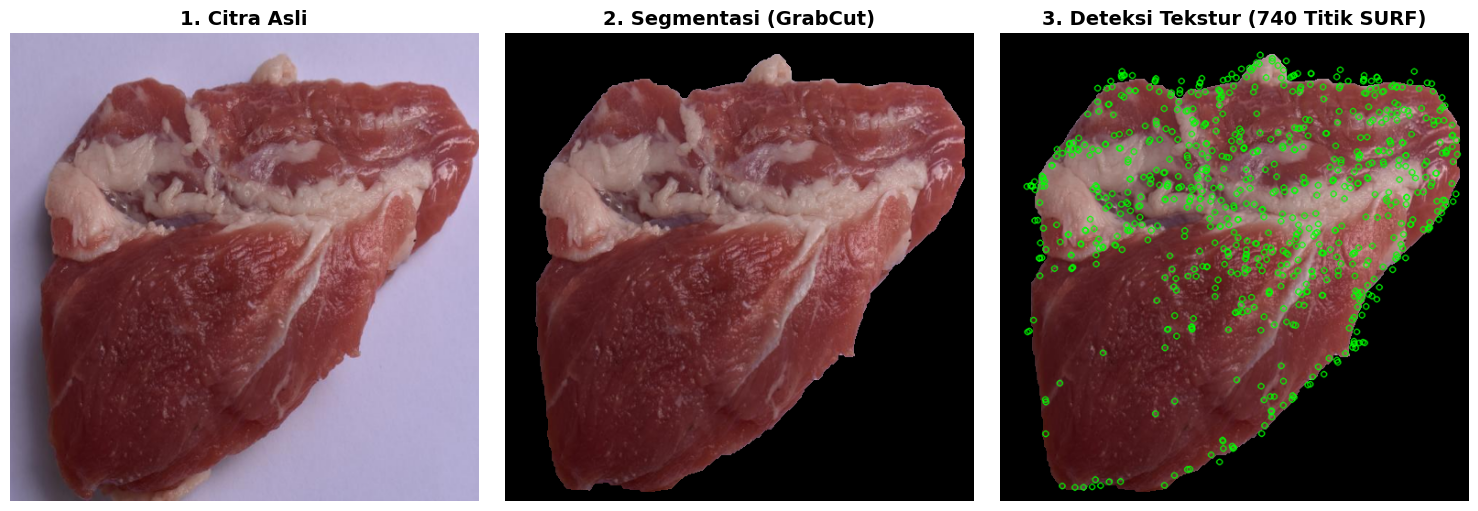

In [5]:
# ═══════════════════════════════════════════════════
# CELL 5 — VISUALISASI PRE-PROCESSING (GRABCUT & SURF)
# ═══════════════════════════════════════════════════
# Sesuaikan path gambar uji
nama_file_uji = "dataset/Segar/1-23-_JPG.rf.e3e6d16fd20d135bf4b68eb2bd0175ca.jpg"

img_asli = cv2.imread(nama_file_uji)

if img_asli is None:
    print(f"Eror: File gambar '{nama_file_uji}' tidak ditemukan.")
else:
    img_resized             = cv2.resize(img_asli, IMG_SIZE)
    img_bersih, mask_daging = remove_background(img_resized)

    surf = cv2.xfeatures2d.SURF_create(300)
    keypoints, _ = surf.detectAndCompute(img_bersih, None)
    img_keypoints = cv2.drawKeypoints(
        img_bersih, keypoints, None,
        color=(0, 255, 0),
        flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT
    )

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    plt.title('1. Citra Asli', fontsize=14, fontweight='bold'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(cv2.cvtColor(img_bersih, cv2.COLOR_BGR2RGB))
    plt.title('2. Segmentasi (GrabCut)', fontsize=14, fontweight='bold'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB))
    plt.title(f'3. Deteksi Tekstur ({len(keypoints)} Titik SURF)', fontsize=14, fontweight='bold'); plt.axis('off')
    plt.tight_layout()
    save_current_figure("preprocessing_grabcut_surf.png")
    plt.show()

In [6]:
# ═══════════════════════════════════════════════════
# CELL 6 — FEATURE WEIGHTER & KOMPONEN PIPELINE
# ═══════════════════════════════════════════════════

class FeatureWeighter(BaseEstimator, TransformerMixin):
    """
    Custom Transformer Scikit-Learn untuk mengamplifikasi fitur warna HSV
    agar kontribusinya seimbang dengan fitur tekstur SURF-BoVW yang berdimensi
    lebih besar, sehingga mengatasi fenomena Curse of Dimensionality.
    
    Hanya indeks fitur 0 s.d. num_hsv_features-1 (fitur warna) yang dikalikan
    dengan hsv_weight; fitur tekstur (indeks sisanya) dibiarkan.
    """
    def __init__(self, hsv_weight: float = 1.0, num_hsv_features: int = 57):
        self.hsv_weight      = hsv_weight
        self.num_hsv_features = num_hsv_features

    def fit(self, X: np.ndarray, y: Optional[np.ndarray] = None) -> 'FeatureWeighter':
        return self  # Stateless transformer

    def transform(self, X: np.ndarray) -> np.ndarray:
        X_weighted = X.copy()
        X_weighted[:, :self.num_hsv_features] *= self.hsv_weight
        return X_weighted


print("✅ FeatureWeighter siap.")
print(f"  Fitur warna yang dibobotkan : indeks 0 – {NUM_HSV_FEATURES - 1}")
print(f"  Fitur tekstur (tidak diubah): indeks {NUM_HSV_FEATURES} – {NUM_HSV_FEATURES + K_CLUSTERS - 1}")

✅ FeatureWeighter siap.
  Fitur warna yang dibobotkan : indeks 0 – 56
  Fitur tekstur (tidak diubah): indeks 57 – 156


In [7]:
# ═══════════════════════════════════════════════════
# CELL 7 — FUNGSI EVALUASI PIPELINE (REVISI BERSIH)
# ═══════════════════════════════════════════════════
#
# PERUBAHAN METODOLOGIS UTAMA dari versi lama:
#
# [FIX #1 — BoVW Leakage]
#   DULU : build_visual_vocabulary(all_image_paths)  ← semua 400 citra
#           → vocab bocor ke data uji di setiap fold
#   KINI : Di dalam setiap fold, vocab KMeans dilatih HANYA dari
#           train_idx, lalu diterapkan ke val_idx.
#
# [FIX #2 — True Hold-Out Evaluation]  [FIX #7: docstring dikoreksi]
#   DULU : grid_search.fit(X, y)
#          best_model = grid_search.best_estimator_
#          y_pred     = cross_val_predict(best_model, X, y)   ← double-dip
#          accuracy   = accuracy_score(y, y_pred)             ← optimistis bias
#   KINI : Model terbaik hasil GridSearch (inner CV 3-fold) diprediksi
#          pada outer validation fold yang TIDAK pernah dilihat selama
#          training maupun hyperparameter tuning. Ini adalah true hold-out
#          evaluation — bukan best_score_ inner CV.
#
# [FIX #3 — Ablation Fairness]
#   DULU : param_grid non-fusi hanya 'rbf', rentang C berbeda
#   KINI : param_grid non-fusi identik cakupan kernel & C dengan fusi
#          agar perbandingan Ablation Study tidak bias akibat pencarian
#          hyperparameter yang tidak setara.
#
# [FIX #9 — Vocab Logging]
#   Fungsi kini mengembalikan best_vocab_fold (vocab KMeans dari fold
#   dengan akurasi outer tertinggi) sebagai elemen ke-6 return tuple.
#   Vocab ini digunakan Cell 12 untuk pelatihan model final.
#
# Signature return (diperbarui):
#   (mean_acc_pct, y_pred_oof, best_estimator, best_params_dict,
#    last_grid_obj, best_vocab_fold)
#   - mean_acc_pct  : float, rata-rata akurasi outer fold hold-out (%)
#   - y_pred_oof    : np.ndarray, prediksi out-of-fold — untuk Confusion Matrix
#   - best_estimator: Pipeline terbaik dari fold dengan akurasi tertinggi
#   - best_params   : dict hyperparameter terbaik
#   - last_grid     : objek GridSearch fold terakhir (untuk plot hsv_weight)
#   - best_vocab    : MiniBatchKMeans vocab dari fold terbaik (untuk deployment)
# ───────────────────────────────────────────────────────────────────────────

def _extract_features_for_fold(
    all_paths: List[str],
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    k: int = K_CLUSTERS,
    image_size: Tuple[int, int] = IMG_SIZE,
    classes: List[str] = CLASSES_NAME
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray,
           np.ndarray, np.ndarray, np.ndarray, np.ndarray,
           MiniBatchKMeans]:
    """
    [Helper internal — dipanggil per fold]
    Membangun kamus visual HANYA dari citra train_idx,
    lalu mengekstrak fitur fusion/HSV/SURF untuk train dan val secara terpisah.
    Mengembalikan: X_fusi_tr, X_hsv_tr, X_surf_tr, y_tr,
                   X_fusi_val, X_hsv_val, X_surf_val, y_val, vocab_fold
    """
    label_map = {cls: i for i, cls in enumerate(classes)}

    def _load_and_extract(paths):
        """Muat gambar dan ekstraksi fitur mentah (tanpa BoVW mapping)."""
        feats_hsv, descs, labels = [], [], []
        for path in paths:
            # Baca label dari nama folder parent
            cls_name = os.path.basename(os.path.dirname(path))
            if cls_name not in label_map:
                continue
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.resize(img, image_size)
            img_clean, mask = remove_background(img)
            feats_hsv.append(extract_hsv_features(img_clean, mask))
            descs.append(extract_surf_descriptors(img_clean))
            labels.append(label_map[cls_name])
        return feats_hsv, descs, labels

    # Kumpulkan semua path terurut sesuai label agar idx bisa dipetakan
    ordered_paths = []
    for cls in classes:
        folder = os.path.join(DATASET_PATH, cls)
        ordered_paths.extend(sorted(glob.glob(os.path.join(folder, "*.*"))))

    train_paths = [ordered_paths[i] for i in train_idx]
    val_paths   = [ordered_paths[i] for i in val_idx]

    # Ekstraksi fitur mentah
    hsv_tr, descs_tr, y_tr   = _load_and_extract(train_paths)
    hsv_val, descs_val, y_val = _load_and_extract(val_paths)

    # Bangun vocab KMeans HANYA dari train [FIX #1]
    train_descs_stacked = [d for d in descs_tr if d is not None and len(d) > 0]
    if not train_descs_stacked:
        raise RuntimeError("Tidak ada deskriptor SURF pada data training fold ini.")
    stacked = np.vstack(train_descs_stacked)
    vocab_fold = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=2000)
    vocab_fold.fit(stacked)

    # BoVW histogram dengan vocab fold
    bovw_tr  = [create_bovw_histogram(d, vocab_fold) for d in descs_tr]
    bovw_val = [create_bovw_histogram(d, vocab_fold) for d in descs_val]

    X_fusi_tr  = np.column_stack([hsv_tr,  bovw_tr])
    X_hsv_tr   = np.array(hsv_tr,  dtype=np.float32)
    X_surf_tr  = np.array(bovw_tr, dtype=np.float32)
    X_fusi_val = np.column_stack([hsv_val, bovw_val])
    X_hsv_val  = np.array(hsv_val,  dtype=np.float32)
    X_surf_val = np.array(bovw_val, dtype=np.float32)
    y_tr_arr   = np.array(y_tr,  dtype=np.int32)
    y_val_arr  = np.array(y_val, dtype=np.int32)

    return (X_fusi_tr, X_hsv_tr, X_surf_tr, y_tr_arr,
            X_fusi_val, X_hsv_val, X_surf_val, y_val_arr,
            vocab_fold)


# Param grid TERPADU — dipakai untuk SEMUA skenario agar perbandingan fair
# (FIX #3: non-fusi juga mendapat kesempatan coba kernel linear)
PARAM_GRID_BASE = {
    'svm__C':      [0.1, 1, 10, 50, 100],
    'svm__gamma':  ['scale', 0.1, 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}
PARAM_GRID_FUSION = {
    **PARAM_GRID_BASE,
    'weighter__hsv_weight': [0.1, 0.5, 1.0, 1.5, 2.0, 3.0],
}


def _build_pipeline(is_fusion: bool) -> Pipeline:
    base_svm = SVC(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        probability=True
    )
    if is_fusion:
        return Pipeline([
            ('scaler',   StandardScaler()),
            ('weighter', FeatureWeighter(num_hsv_features=NUM_HSV_FEATURES)),
            ('svm',      base_svm),
        ])
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    base_svm),
    ])


def evaluate_model_clean(
    scenario: str,         # 'fusion' | 'hsv' | 'surf'
    all_paths: List[str],
    n_folds: int = N_FOLDS,
    k: int = K_CLUSTERS,
    image_size: Tuple[int, int] = IMG_SIZE
) -> Tuple[float, np.ndarray, Any, dict, Any, Any]:
    """
    Evaluasi pipeline ML yang metodologis bersih dengan nested CV:
    - Outer loop : StratifiedKFold 5-fold (true hold-out per fold)     [FIX #1, #2]
    - Inner loop : GridSearchCV StratifiedKFold 3-fold (HP tuning)     [FIX #3]
    - Vocab KMeans dibangun per fold dari data latih saja              [FIX #1]
    - Akurasi fold = accuracy_score(y_val_outer, y_pred_outer)         [FIX #7]
      → Dievaluasi pada outer validation fold yang sepenuhnya tidak
        terlihat saat training maupun hyperparameter search.
    - Param grid seragam untuk semua skenario                          [FIX #3]
    - best_vocab_fold dikembalikan untuk deployment                    [FIX #9]

    Returns:
        mean_acc_pct   : rata-rata akurasi outer fold hold-out (%)
        y_pred_oof     : prediksi out-of-fold (untuk Confusion Matrix)
        best_estimator : Pipeline terbaik dari fold dengan akurasi tertinggi
        best_params    : dict hyperparameter terbaik
        last_grid      : objek GridSearch fold terakhir (untuk plot hsv_weight)
        best_vocab     : MiniBatchKMeans vocab dari fold terbaik (untuk deployment)
    """
    is_fusion  = (scenario == 'fusion')
    cv         = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    param_grid = PARAM_GRID_FUSION if is_fusion else PARAM_GRID_BASE

    # Buat label array dari ordered_paths agar bisa pakai StratifiedKFold
    ordered_paths, y_all = [], []
    label_map = {cls: i for i, cls in enumerate(CLASSES_NAME)}
    for cls in CLASSES_NAME:
        folder = os.path.join(DATASET_PATH, cls)
        paths  = sorted(glob.glob(os.path.join(folder, "*.*")))
        ordered_paths.extend(paths)
        y_all.extend([label_map[cls]] * len(paths))
    y_all = np.array(y_all, dtype=np.int32)

    fold_scores       = []
    fold_details      = []   # [FIX #8] per-fold detail untuk tabel statistik
    oof_preds         = np.empty(len(y_all), dtype=np.int32)
    best_estimator    = None
    best_score_global = -1.0
    best_params_global = {}
    best_vocab_global  = None   # [FIX #9] vocab dari fold terbaik
    last_grid = None

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(ordered_paths, y_all), 1):
        print(f"  Fold {fold_idx}/{n_folds}...", end=" ", flush=True)

        # Ekstraksi fitur dengan vocab bersih per fold [FIX #1]
        (X_fusi_tr, X_hsv_tr, X_surf_tr, y_tr,
         X_fusi_val, X_hsv_val, X_surf_val, y_val,
         vocab_fold) = _extract_features_for_fold(
            ordered_paths, train_idx, val_idx, k=k, image_size=image_size
        )

        if scenario == 'fusion':
            X_tr, X_val = X_fusi_tr, X_fusi_val
        elif scenario == 'hsv':
            X_tr, X_val = X_hsv_tr, X_hsv_val
        else:
            X_tr, X_val = X_surf_tr, X_surf_val

        # GridSearch dilatih pada X_tr saja (inner CV 3-fold)
        pipeline    = _build_pipeline(is_fusion)
        inner_cv    = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        grid_search = GridSearchCV(
            pipeline, param_grid,
            cv=inner_cv, scoring='accuracy', n_jobs=N_JOBS, refit=True
        )
        grid_search.fit(X_tr, y_tr)
        last_grid = grid_search

        # True hold-out: evaluasi pada outer val fold [FIX #2 / FIX #7]
        y_val_pred         = grid_search.best_estimator_.predict(X_val)
        fold_acc           = accuracy_score(y_val, y_val_pred) * 100
        oof_preds[val_idx] = y_val_pred
        fold_scores.append(fold_acc)

        # [FIX #8] simpan detail per fold
        fold_details.append({
            'Fold': fold_idx,
            'Akurasi (%)': round(fold_acc, 2),
            'n_train': len(y_tr),
            'n_val': len(y_val),
            'best_kernel': grid_search.best_params_.get('svm__kernel', '-'),
            'best_C': grid_search.best_params_.get('svm__C', '-'),
        })
        print(f"acc={fold_acc:.2f}% | params={grid_search.best_params_}")

        # Simpan estimator & vocab terbaik berdasarkan skor fold [FIX #9]
        if fold_acc > best_score_global:
            best_score_global  = fold_acc
            best_estimator     = grid_search.best_estimator_
            best_params_global = grid_search.best_params_
            best_vocab_global  = vocab_fold   # vocab dari fold ini

    mean_acc = float(np.mean(fold_scores))
    std_acc  = float(np.std(fold_scores))
    print(f"  ➜ Mean Accuracy : {mean_acc:.2f}% ± {std_acc:.2f}%")
    print(f"  ➜ Min / Max     : {min(fold_scores):.2f}% / {max(fold_scores):.2f}%")

    # [FIX #8] Cetak tabel per-fold
    df_folds = pd.DataFrame(fold_details)
    print("\n" + df_folds.to_string(index=False))

    return mean_acc, oof_preds, best_estimator, best_params_global, last_grid, best_vocab_global


print("✅ Fungsi evaluasi pipeline (metodologis bersih v2.1) siap.")
print("   [FIX #7] Docstring akurasi dikoreksi ke outer fold hold-out.")
print("   [FIX #8] Tabel per-fold aktif.")
print("   [FIX #9] best_vocab_fold dikembalikan.")


✅ Fungsi evaluasi pipeline (metodologis bersih v2.1) siap.
   [FIX #7] Docstring akurasi dikoreksi ke outer fold hold-out.
   [FIX #8] Tabel per-fold aktif.
   [FIX #9] best_vocab_fold dikembalikan.


In [8]:
# ═══════════════════════════════════════════════════
# CELL 8 — MAIN PROGRAM: ABLATION STUDY
# ═══════════════════════════════════════════════════

# Konfigurasi WandB (opsional — isi API key di file .env)
load_env_file('.env')
WANDB_API_KEY  = os.getenv('WANDB_API_KEY', '')
WANDB_PROJECT  = 'beefresearch-TA'
WANDB_RUN_NAME = 'svm-surf-hsv-experiment-9'

wandb_run = start_wandb_run(
    project_name=WANDB_PROJECT,
    config={
        'dataset_path': DATASET_PATH,
        'k_clusters': K_CLUSTERS,
        'img_size': IMG_SIZE,
        'random_state': RANDOM_STATE,
        'n_folds': N_FOLDS,
        'fix_bovw_leakage': True,
        'fix_double_dipping': True,
        'ablation_fair_grid': True,
        'fix_bovw_normalization': True,
        'fix_vocab_logging': True,
    },
    api_key=WANDB_API_KEY,
    run_name=WANDB_RUN_NAME
)

all_image_paths = []
for cls in CLASSES_NAME:
    all_image_paths.extend(sorted(glob.glob(os.path.join(DATASET_PATH, cls, "*.*"))))

if not all_image_paths:
    print("❌ ERROR: Dataset tidak ditemukan. Periksa DATASET_PATH.")
else:
    print(f"Total dataset: {len(all_image_paths)} gambar\n")
    print("=" * 65)

    # ── Skenario 1: Hanya SURF (Tekstur) ──────────────────────────
    print("\n[1/3] Menguji Skenario: HANYA TEKSTUR (SURF-BoVW 100D)")
    acc_surf, pred_surf, best_surf_model, params_surf, _, vocab_surf = evaluate_model_clean(
        scenario='surf', all_paths=all_image_paths
    )
    print(f"  ✅ Akurasi SURF  : {acc_surf:.2f}%")
    print(f"  Parameter terbaik: {params_surf}")
    if wandb_run:
        log_wandb_metrics({'accuracy_surf': acc_surf, 'best_params_surf': str(params_surf)}, step=1)

    # ── Skenario 2: Hanya HSV (Warna) ─────────────────────────────
    print("\n[2/3] Menguji Skenario: HANYA WARNA (HSV 57D)")
    acc_hsv, pred_hsv, best_hsv_model, params_hsv, _, _ = evaluate_model_clean(
        scenario='hsv', all_paths=all_image_paths
    )
    print(f"  ✅ Akurasi HSV   : {acc_hsv:.2f}%")
    print(f"  Parameter terbaik: {params_hsv}")
    if wandb_run:
        log_wandb_metrics({'accuracy_hsv': acc_hsv, 'best_params_hsv': str(params_hsv)}, step=2)

    # ── Skenario 3: Fusi Berbobot (HSV + SURF) ────────────────────
    print("\n[3/3] Menguji Skenario: FUSI FITUR BERBOBOT (157D)")
    acc_fusi, pred_fusi, best_fusion_model, params_fusi, grid_fusi, vocab_fusi = evaluate_model_clean(
        scenario='fusion', all_paths=all_image_paths
    )
    print(f"  ✅ Akurasi FUSI  : {acc_fusi:.2f}%")
    print(f"  Parameter terbaik: {params_fusi}")
    if wandb_run:
        log_wandb_metrics({'accuracy_fusi': acc_fusi, 'best_params_fusi': str(params_fusi)}, step=3)

    print("\n" + "=" * 65)
    print("RINGKASAN ABLATION STUDY (akurasi outer fold hold-out — metodologis bersih)")
    print(f"  Skenario 1 - SURF-BoVW : {acc_surf:.2f}%")
    print(f"  Skenario 2 - HSV       : {acc_hsv:.2f}%")
    print(f"  Skenario 3 - Fusi      : {acc_fusi:.2f}%")
    print("=" * 65)
    print("Catatan metodologi: Akurasi di atas dihitung dari prediksi pada")
    print("outer validation fold yang tidak pernah dilihat model selama")
    print("training maupun hyperparameter tuning (true nested CV hold-out).")

    # Label asli (ground truth) untuk Confusion Matrix
    y_label = []
    label_map = {cls: i for i, cls in enumerate(CLASSES_NAME)}
    for cls in CLASSES_NAME:
        paths = sorted(glob.glob(os.path.join(DATASET_PATH, cls, "*.*")))
        y_label.extend([label_map[cls]] * len(paths))
    y_label = np.array(y_label, dtype=np.int32)

if wandb_run:
    finish_wandb_run()


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: abrarwahid (tsagaprojects). Use `wandb login --relogin` to force relogin


Total dataset: 400 gambar


[1/3] Menguji Skenario: HANYA TEKSTUR (SURF-BoVW 100D)
  Fold 1/5... acc=66.25% | params={'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Fold 2/5... acc=68.75% | params={'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Fold 3/5... acc=68.75% | params={'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Fold 4/5... acc=75.00% | params={'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Fold 5/5... acc=62.50% | params={'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  ➜ Mean Accuracy : 68.25% ± 4.08%
  ➜ Min / Max     : 62.50% / 75.00%

 Fold  Akurasi (%)  n_train  n_val best_kernel  best_C
    1        66.25      320     80         rbf      10
    2        68.75      320     80         rbf      10
    3        68.75      320     80         rbf      10
    4        75.00      320     80         rbf      10
    5        62.50      320     80         rbf       1
  ✅ Akurasi SURF  : 68.25%
  Parameter terbaik

accuracy_fusi,▁
accuracy_hsv,▁
accuracy_surf,▁
accuracy_fusi,88.75
accuracy_hsv,82.5
accuracy_surf,68.25
best_params_fusi,"{'svm__C': 10, 'svm_..."
best_params_hsv,"{'svm__C': 100, 'svm..."
best_params_surf,"{'svm__C': 10, 'svm_..."


Gambar disimpan: output-img/evaluasi_perbandingan_akurasi.png


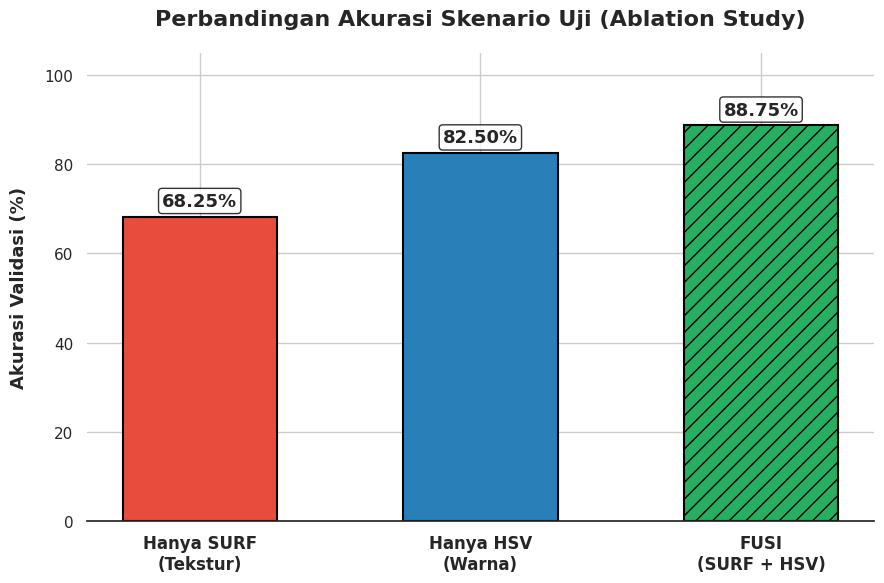


CONFUSION MATRIX — SKENARIO 1 (SURF):
Gambar disimpan: output-img/evaluasi_confusion_matrix_skenario_1_surf.png


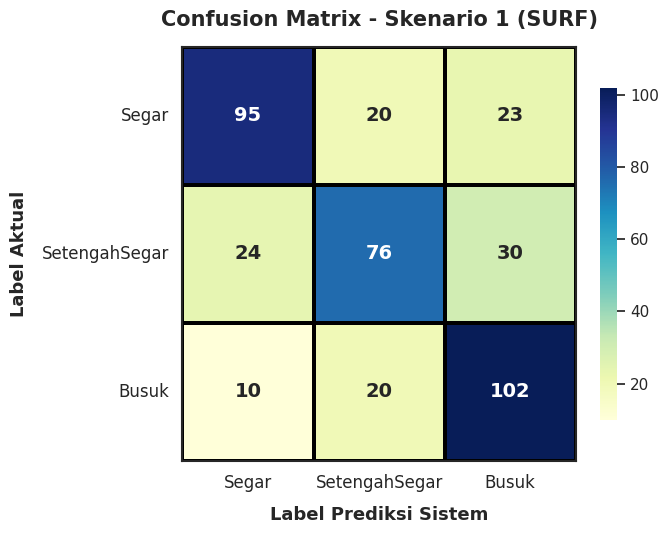


CONFUSION MATRIX — SKENARIO 2 (HSV):
Gambar disimpan: output-img/evaluasi_confusion_matrix_skenario_2_hsv.png


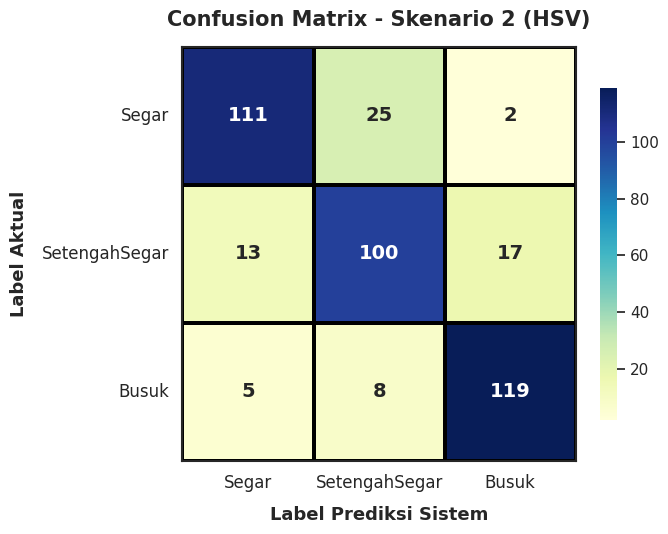


CONFUSION MATRIX — SKENARIO 3 (FUSI):
Gambar disimpan: output-img/evaluasi_confusion_matrix_metode_fusi_hsv_surf.png


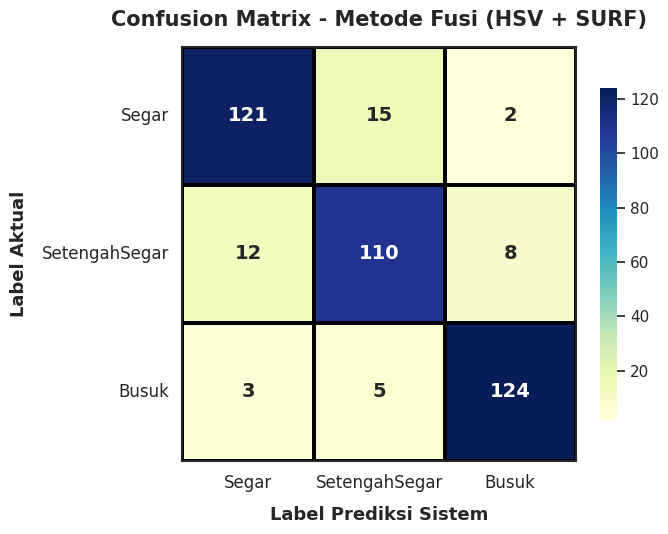


LAPORAN KLASIFIKASI RINCI — MODEL FUSI:
               precision    recall  f1-score   support

        Segar       0.89      0.88      0.88       138
SetengahSegar       0.85      0.85      0.85       130
        Busuk       0.93      0.94      0.93       132

     accuracy                           0.89       400
    macro avg       0.89      0.89      0.89       400
 weighted avg       0.89      0.89      0.89       400



In [9]:
# ═══════════════════════════════════════════════════
# CELL 9 — VISUALISASI HASIL EVALUASI
# ═══════════════════════════════════════════════════

def plot_accuracy_comparison(acc_hsv: float, acc_surf: float, acc_fusi: float) -> None:
    """Grafik batang perbandingan akurasi Ablation Study."""
    sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.15", "axes.linewidth": 1.25})
    methods    = ['Hanya SURF\n(Tekstur)', 'Hanya HSV\n(Warna)', 'FUSI\n(SURF + HSV)']
    accuracies = [acc_surf, acc_hsv, acc_fusi]
    warna_bar  = ['#e74c3c', '#2980b9', '#27ae60']

    plt.figure(figsize=(9, 6))
    bars = plt.bar(methods, accuracies, color=warna_bar,
                   edgecolor='black', linewidth=1.5, width=0.55)
    bars[2].set_hatch('//')
    plt.ylim(0, 105)
    plt.ylabel('Akurasi Validasi (%)', fontsize=13, fontweight='bold', labelpad=12)
    plt.title('Perbandingan Akurasi Skenario Uji (Ablation Study)',
              fontsize=16, fontweight='bold', pad=20)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 1.5, f"{yval:.2f}%",
                 ha='center', va='bottom', fontsize=13, fontweight='bold',
                 bbox=dict(facecolor='white', edgecolor='black',
                           boxstyle='round,pad=0.2', alpha=0.8))
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=11)
    sns.despine(left=True, top=True, right=True)
    plt.tight_layout()
    save_current_figure("evaluasi_perbandingan_akurasi.png")
    plt.show()


def plot_beautiful_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    classes: List[str],
    title: str
) -> None:
    """Heatmap Confusion Matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5.5))
    ax = sns.heatmap(
        cm, annot=True, fmt='d', cmap='YlGnBu',
        xticklabels=classes, yticklabels=classes,
        annot_kws={"size": 14, "weight": "bold"},
        linewidths=1.5, linecolor='black', cbar_kws={'shrink': .8}
    )
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    plt.title(title, fontsize=15, fontweight='bold', pad=15)
    plt.ylabel('Label Aktual', fontsize=13, fontweight='bold', labelpad=10)
    plt.xlabel('Label Prediksi Sistem', fontsize=13, fontweight='bold', labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)
    plt.tight_layout()
    save_current_figure(f"evaluasi_{make_safe_filename(title)}.png")
    plt.show()


# ── Pemanggilan Grafik ───────────────────────────────────────────
if 'acc_fusi' in dir() or 'acc_fusi' in locals():
    # 1. Grafik batang Ablation Study
    plot_accuracy_comparison(acc_hsv, acc_surf, acc_fusi)

    # 2. Confusion Matrix semua skenario
    print("\nCONFUSION MATRIX — SKENARIO 1 (SURF):")
    plot_beautiful_confusion_matrix(y_label, pred_surf, CLASSES_NAME,
                                    'Confusion Matrix - Skenario 1 (SURF)')
    print("\nCONFUSION MATRIX — SKENARIO 2 (HSV):")
    plot_beautiful_confusion_matrix(y_label, pred_hsv, CLASSES_NAME,
                                    'Confusion Matrix - Skenario 2 (HSV)')
    print("\nCONFUSION MATRIX — SKENARIO 3 (FUSI):")
    plot_beautiful_confusion_matrix(y_label, pred_fusi, CLASSES_NAME,
                                    'Confusion Matrix - Metode Fusi (HSV + SURF)')

    # 3. Laporan klasifikasi rinci model fusi
    print("\nLAPORAN KLASIFIKASI RINCI — MODEL FUSI:")
    print(classification_report(y_label, pred_fusi, target_names=CLASSES_NAME))
else:
    print("Jalankan Cell 8 (Main Program) terlebih dahulu.")

Gambar disimpan: output-img/evaluasi_pengaruh_hsv_weight.png


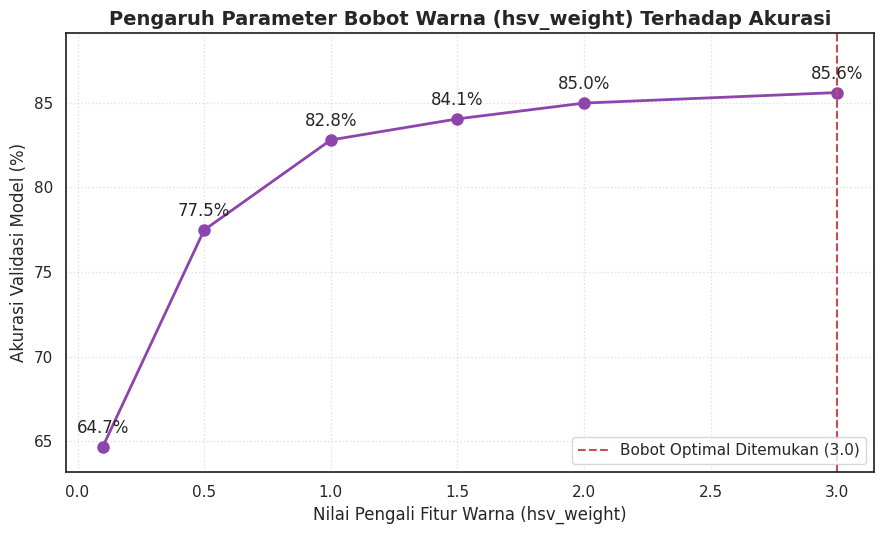

In [10]:
# ═══════════════════════════════════════════════════
# CELL 10 — VISUALISASI TAMBAHAN
# ═══════════════════════════════════════════════════

def plot_hsv_weight_impact_dynamic(grid_search_obj) -> None:
    """
    Grafik pengaruh parameter hsv_weight terhadap akurasi validasi,
    diambil dari cv_results_ GridSearch fold terakhir (pada data train fold).
    """
    results     = pd.DataFrame(grid_search_obj.cv_results_)
    best_params = grid_search_obj.best_params_
    best_c      = best_params.get('svm__C')
    best_kernel = best_params.get('svm__kernel')
    best_gamma  = best_params.get('svm__gamma')
    best_weight = best_params.get('weighter__hsv_weight')

    filtered = results[
        (results['param_svm__kernel'] == best_kernel) &
        (results['param_svm__C']      == best_c)      &
        (results['param_svm__gamma']  == best_gamma)
    ].sort_values('param_weighter__hsv_weight')

    weights = filtered['param_weighter__hsv_weight'].tolist()
    scores  = (filtered['mean_test_score'] * 100).tolist()

    plt.figure(figsize=(9, 5.5))
    plt.plot(weights, scores, marker='o', linestyle='-',
             color='#8e44ad', linewidth=2, markersize=8)
    plt.axvline(x=best_weight, color='r', linestyle='--',
                label=f'Bobot Optimal Ditemukan ({best_weight})')
    plt.ylim(min(scores) - 1.5, max(scores) + 3.5)
    plt.title('Pengaruh Parameter Bobot Warna (hsv_weight) Terhadap Akurasi',
              fontsize=14, fontweight='bold')
    plt.xlabel('Nilai Pengali Fitur Warna (hsv_weight)', fontsize=12)
    plt.ylabel('Akurasi Validasi Model (%)', fontsize=12)
    for i, txt in enumerate(scores):
        plt.annotate(f"{txt:.1f}%", (weights[i], scores[i]),
                     textcoords="offset points", xytext=(0, 10), ha='center')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    save_current_figure("evaluasi_pengaruh_hsv_weight.png")
    plt.show()


if 'grid_fusi' in dir() or 'grid_fusi' in locals():
    plot_hsv_weight_impact_dynamic(grid_fusi)
else:
    print("Jalankan Cell 8 terlebih dahulu.")

In [11]:
# ═══════════════════════════════════════════════════
# CELL 11 — VISUALISASI DEKOMPOSISI HSV & HISTOGRAM 1D
# ═══════════════════════════════════════════════════

def plot_hsv_decomposition(image_path: str) -> None:
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Citra tidak ditemukan: {image_path}")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)

    # Histogram 1D menggunakan calcHist agar konsisten dengan extract_hsv_features
    hist_h = cv2.calcHist([img_hsv], [0], None, [16], [0, 180]).flatten()
    hist_s = cv2.calcHist([img_hsv], [1], None, [16], [0, 256]).flatten()
    hist_v = cv2.calcHist([img_hsv], [2], None, [16], [0, 256]).flatten()

    fig = plt.figure(figsize=(16, 7))
    plt.suptitle("Dekomposisi Ruang Warna HSV dan Ekstraksi Histogram 1D",
                 fontsize=16, fontweight='bold', y=1.02)

    plt.subplot(2, 4, 1); plt.imshow(img_rgb)
    plt.title('Citra Asli (RGB)', fontweight='bold', fontsize=12); plt.axis('off')
    plt.subplot(2, 4, 2); plt.imshow(h, cmap='hsv')
    plt.title('Kanal Hue (H)', fontweight='bold', fontsize=12); plt.axis('off')
    plt.subplot(2, 4, 3); plt.imshow(s, cmap='gray')
    plt.title('Kanal Saturation (S)', fontweight='bold', fontsize=12); plt.axis('off')
    plt.subplot(2, 4, 4); plt.imshow(v, cmap='gray')
    plt.title('Kanal Value (V)', fontweight='bold', fontsize=12); plt.axis('off')

    plt.subplot(2, 4, 5)
    plt.text(0.5, 0.5, "Ekstraksi\nHistogram 1D\n(16 Bins)",
             fontsize=14, ha='center', va='center', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='#f0f0f0', edgecolor='gray'))
    plt.axis('off')

    for idx, (hist, color, label) in enumerate(
        zip([hist_h, hist_s, hist_v],
            ['red', 'green', 'blue'],
            ['Histogram Hue (16 Bins)', 'Histogram Saturation (16 Bins)', 'Histogram Value (16 Bins)'])
    ):
        plt.subplot(2, 4, 6 + idx)
        plt.plot(hist, color=color, marker='o', linewidth=2)
        plt.title(label, fontsize=11)
        plt.xlabel('Bins (0-15)')
        if idx == 0:
            plt.ylabel('Frekuensi Piksel')
        plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    nama = make_safe_filename(os.path.splitext(os.path.basename(image_path))[0])
    save_current_figure(f"hsv_dekomposisi_{nama}.png")
    plt.show()


# Sesuaikan path gambar uji
path_contoh_gambar = "test_img/segar4.webp"
plot_hsv_decomposition(path_contoh_gambar)

Citra tidak ditemukan: test_img/segar4.webp


In [12]:
# ═══════════════════════════════════════════════════
# CELL 12 — SAVE MODEL & FINAL TRAINING
# ═══════════════════════════════════════════════════
#
# STRATEGI DEPLOYMENT (v2.1 — FIX #9):
#
# Ablation Study (Cell 8) menggunakan nested CV murni untuk estimasi
# performa yang jujur. Karena vocab KMeans dibangun per fold, tidak ada
# satu vocab global yang langsung bisa disimpan dari Cell 8.
#
# Solusi: setelah hyperparameter terbaik diketahui dari Ablation Study,
# lakukan FINAL TRAINING pada SELURUH dataset:
#   1. Bangun vocab KMeans global dari semua citra (train_final_vocab)
#   2. Ekstrak seluruh fitur fusi menggunakan vocab tersebut
#   3. Latih Pipeline SVM dengan hyperparameter terbaik hasil ablation
#   4. Simpan kedua artefak: fusi_model.pkl + kmeans_vocab.pkl
#
# Model final ini yang digunakan untuk inferensi (Cell 13).
# Akurasi yang dilaporkan di jurnal tetap berasal dari Cell 8 (CV bersih).
# ─────────────────────────────────────────────────────────────────────

import joblib

def save_trained_models(fusion_model: Any, kmeans_model: Any, save_dir: str = ".") -> None:
    """Simpan Pipeline SVM fusi dan vocab KMeans ke disk."""
    os.makedirs(os.path.join(save_dir, 'models'), exist_ok=True)
    svm_path    = os.path.join(save_dir, 'models', 'fusi_model.pkl')
    kmeans_path = os.path.join(save_dir, 'models', 'kmeans_vocab.pkl')
    try:
        joblib.dump(fusion_model, svm_path)
        print(f"  [BERHASIL] Model SVM Fusi disimpan : {svm_path}")
        if kmeans_model is not None:
            joblib.dump(kmeans_model, kmeans_path)
            print(f"  [BERHASIL] Vocab KMeans disimpan  : {kmeans_path}")
        else:
            print(f"  [SKIP] kmeans_model=None — tidak ada yang disimpan di {kmeans_path}")
    except Exception as e:
        print(f"  [GAGAL] {e}")


def train_final_model(
    best_params: dict,
    k: int = K_CLUSTERS,
    image_size: Tuple[int, int] = IMG_SIZE,
    save_dir: str = "."
) -> Tuple[Any, MiniBatchKMeans]:
    """
    Latih model final pada SELURUH dataset menggunakan hyperparameter
    terbaik yang ditemukan pada Ablation Study (Cell 8).  [FIX #9]

    Langkah:
      1. Muat & ekstrak semua citra → HSV features + SURF descriptors
      2. Bangun vocab KMeans global dari SELURUH deskriptor SURF
      3. Buat BoVW histogram semua citra
      4. Fusi: concat(HSV, BoVW) → 157D
      5. Latih Pipeline (Scaler → Weighter → SVM) dengan best_params
      6. Simpan model + vocab

    Returns:
        final_pipeline : Pipeline SVM fusi yang sudah dilatih
        final_vocab    : MiniBatchKMeans vocab global
    """
    print("\n" + "=" * 65)
    print("FINAL MODEL TRAINING (seluruh dataset)")
    print(f"  Hyperparameter: {best_params}")
    print("=" * 65)

    label_map = {cls: i for i, cls in enumerate(CLASSES_NAME)}
    all_hsv, all_descs, all_labels = [], [], []

    for cls in CLASSES_NAME:
        folder = os.path.join(DATASET_PATH, cls)
        paths  = sorted(glob.glob(os.path.join(folder, "*.*")))
        print(f"  Memuat {cls}: {len(paths)} citra...")
        for path in paths:
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.resize(img, image_size)
            img_clean, mask = remove_background(img)
            all_hsv.append(extract_hsv_features(img_clean, mask))
            all_descs.append(extract_surf_descriptors(img_clean))
            all_labels.append(label_map[cls])

    # Bangun vocab global dari SELURUH deskriptor
    valid_descs = [d for d in all_descs if d is not None and len(d) > 0]
    if not valid_descs:
        raise RuntimeError("Tidak ada deskriptor SURF yang valid pada seluruh dataset.")
    stacked_all = np.vstack(valid_descs)
    print(f"\n  Membangun vocab KMeans global dari {stacked_all.shape[0]:,} deskriptor...")
    final_vocab = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=2000)
    final_vocab.fit(stacked_all)
    print("  ✅ Vocab KMeans global selesai.")

    # Buat fitur fusi dengan vocab global
    all_bovw  = [create_bovw_histogram(d, final_vocab) for d in all_descs]
    X_final   = np.column_stack([all_hsv, all_bovw]).astype(np.float32)
    y_final   = np.array(all_labels, dtype=np.int32)
    print(f"  Dimensi fitur fusi final: {X_final.shape}")

    # Bangun Pipeline dengan hyperparameter terbaik
    hsv_weight_val = best_params.get('weighter__hsv_weight', 1.0)
    C_val          = best_params.get('svm__C', 10)
    kernel_val     = best_params.get('svm__kernel', 'rbf')
    gamma_val      = best_params.get('svm__gamma', 'scale')

    final_pipeline = Pipeline([
        ('scaler',   StandardScaler()),
        ('weighter', FeatureWeighter(
            hsv_weight=hsv_weight_val,
            num_hsv_features=NUM_HSV_FEATURES
        )),
        ('svm', SVC(
            C=C_val, kernel=kernel_val, gamma=gamma_val,
            random_state=RANDOM_STATE,
            class_weight='balanced',
            probability=True
        )),
    ])
    final_pipeline.fit(X_final, y_final)
    train_acc = accuracy_score(y_final, final_pipeline.predict(X_final)) * 100
    print(f"  Akurasi training (in-sample, informatif saja): {train_acc:.2f}%")
    print("  (Akurasi generalisasi yang valid: lihat hasil Cell 8)")

    save_trained_models(final_pipeline, final_vocab, save_dir)
    return final_pipeline, final_vocab


# ── Eksekusi Final Training ──────────────────────────────────────
if 'params_fusi' in dir() or 'params_fusi' in locals():
    final_fusion_model, final_kmeans_vocab = train_final_model(
        best_params=params_fusi,
        save_dir='.'
    )
    print("\n✅ Model final dan vocab KMeans berhasil disimpan.")
    print("   Gunakan ./models/fusi_model.pkl + ./models/kmeans_vocab.pkl untuk inferensi.")
else:
    print("Jalankan Cell 8 (Ablation Study) terlebih dahulu untuk mendapatkan params_fusi.")



FINAL MODEL TRAINING (seluruh dataset)
  Hyperparameter: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'weighter__hsv_weight': 3.0}
  Memuat Segar: 138 citra...
  Memuat SetengahSegar: 130 citra...
  Memuat Busuk: 132 citra...

  Membangun vocab KMeans global dari 453,237 deskriptor...
  ✅ Vocab KMeans global selesai.
  Dimensi fitur fusi final: (400, 157)
  Akurasi training (in-sample, informatif saja): 100.00%
  (Akurasi generalisasi yang valid: lihat hasil Cell 8)
  [BERHASIL] Model SVM Fusi disimpan : ./models/fusi_model.pkl
  [BERHASIL] Vocab KMeans disimpan  : ./models/kmeans_vocab.pkl

✅ Model final dan vocab KMeans berhasil disimpan.
   Gunakan ./models/fusi_model.pkl + ./models/kmeans_vocab.pkl untuk inferensi.


In [13]:
# ═══════════════════════════════════════════════════
# CELL 13 — UJI PREDIKSI (INFERENSI)
# ═══════════════════════════════════════════════════
#
# CATATAN [FIX #10]:
# Inferensi menggunakan model dan vocab yang dihasilkan Cell 12
# (train_final_model). Kedua artefak bisa dimuat dari disk
# (./models/fusi_model.pkl dan ./models/kmeans_vocab.pkl)
# ATAU langsung dari variabel in-memory jika Cell 12 sudah dijalankan.
# ─────────────────────────────────────────────────────────────────

def uji_prediksi_gambar(
    image_path: str,
    svm_model: Any = None,
    kmeans_model: Any = None,
    svm_path: str = "./models/fusi_model.pkl",
    kmeans_path: str = "./models/kmeans_vocab.pkl"
) -> None:
    """
    Prediksi kesegaran daging sapi dari satu citra.

    Prioritas model:
      1. Gunakan svm_model & kmeans_model dari parameter (in-memory)
      2. Fallback: muat dari svm_path & kmeans_path (disk)

    Pastikan model berasal dari train_final_model() (Cell 12) agar
    vocab KMeans konsisten dengan pipeline yang disimpan.  [FIX #10]
    """
    print("Start Prediction...\n")

    # ── Muat model (in-memory atau dari disk) ────────────────────
    if svm_model is None or kmeans_model is None:
        try:
            svm_model    = joblib.load(svm_path)
            kmeans_model = joblib.load(kmeans_path)
            print(f"  Model dimuat dari disk: {svm_path}, {kmeans_path}")
        except Exception as e:
            print(f"❌ Gagal memuat model dari disk: {e}")
            return
    else:
        print("  Model dimuat dari memori (hasil Cell 12).")

    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Gambar tidak ditemukan: {image_path}")
        return

    # ── Ekstraksi fitur (pipeline konsisten dengan training) ─────
    img_resized          = cv2.resize(img, IMG_SIZE)
    img_bersih, mask     = remove_background(img_resized)
    fitur_hsv            = extract_hsv_features(img_bersih, mask)
    deskriptor_surf      = extract_surf_descriptors(img_bersih)
    # Gunakan vocab dari final_kmeans_vocab (konsisten dengan model) [FIX #10]
    fitur_tekstur        = create_bovw_histogram(deskriptor_surf, kmeans_model)
    fitur_gabungan       = np.concatenate([fitur_hsv, fitur_tekstur]).reshape(1, -1)

    # ── Visualisasi keypoints SURF ───────────────────────────────
    surf_vis         = cv2.xfeatures2d.SURF_create(300)
    keypoints, _     = surf_vis.detectAndCompute(img_bersih, None)
    img_keypoints    = cv2.drawKeypoints(img_bersih, keypoints, None,
                                         color=(0, 255, 0),
                                         flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT)

    # ── Prediksi ─────────────────────────────────────────────────
    indeks_prediksi  = svm_model.predict(fitur_gabungan)[0]
    persentase_yakin = svm_model.predict_proba(fitur_gabungan)[0][indeks_prediksi] * 100
    daftar_kelas     = ['Segar', 'Setengah Segar', 'Busuk']
    hasil_kelas      = daftar_kelas[indeks_prediksi]

    print("HASIL DIAGNOSIS SISTEM:")
    print(f"  Prediksi Kesegaran : {hasil_kelas}")
    print(f"  Tingkat Keyakinan  : {persentase_yakin:.2f}%")
    print(f"  Titik Tekstur SURF : {len(keypoints)} keypoints")

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    plt.title("1. Citra Input", fontweight='bold'); plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB))
    plt.title(f"2. Bukti Fitur ({len(keypoints)} Titik SURF)", fontweight='bold'); plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_bersih, cv2.COLOR_BGR2RGB))
    warna = 'green' if hasil_kelas == 'Segar' else 'orange' if hasil_kelas == 'Setengah Segar' else 'red'
    plt.title(f"3. Prediksi: {hasil_kelas} ({persentase_yakin:.1f}%)",
              fontweight='bold', color=warna)
    plt.axis('off')
    plt.tight_layout()
    nama = make_safe_filename(os.path.splitext(os.path.basename(image_path))[0])
    save_current_figure(f"prediksi_{nama}.png")
    plt.show()


# ── Eksekusi Inferensi ───────────────────────────────────────────
# Opsi A: Gunakan model in-memory dari Cell 12 (lebih cepat, tidak perlu baca disk)
# Opsi B: Muat dari disk (berguna jika Cell 12 tidak dijalankan di sesi ini)

PATH_GAMBAR_TEST = "test_img/segar4.webp"   # Sesuaikan path

if 'final_fusion_model' in dir() or 'final_fusion_model' in locals():
    # Opsi A — in-memory [FIX #10: vocab konsisten]
    uji_prediksi_gambar(
        image_path=PATH_GAMBAR_TEST,
        svm_model=final_fusion_model,
        kmeans_model=final_kmeans_vocab
    )
else:
    # Opsi B — muat dari disk
    print("Variabel in-memory tidak ditemukan. Memuat model dari disk...")
    uji_prediksi_gambar(
        image_path=PATH_GAMBAR_TEST,
        svm_path="./models/fusi_model.pkl",
        kmeans_path="./models/kmeans_vocab.pkl"
    )


Start Prediction...

  Model dimuat dari memori (hasil Cell 12).
❌ Gambar tidak ditemukan: test_img/segar4.webp
